# 02 — Nettoyage Sunbird (reproduit "post-processing" du papier)

Reproduit la pipeline de nettoyage de :
> *Noise mapping and ambient sound recordings of the urban environment in Uganda*
> Nsumba et al., Scientific Data, 2026

Étapes (section "post-processing and privacy" du papier) :
1. Chargement du dataset
2. Suppression des doublons (hash métadonnées : submitter + timestamp + GPS)
3. Filtre qualité GPS (accuracy)
4. Statistiques descriptives
5. Sauvegarde de `sunbird_clean.csv` → utilisé par les notebooks 03, 04, 05

In [1]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

# Token HF chargé depuis .env (gitignoré)
from dotenv import load_dotenv
import os
load_dotenv('../.env')
HF_TOKEN = os.environ['HF_TOKEN']

ds = load_dataset('Sunbird/urban-noise-uganda-61k', 'small', token=HF_TOKEN)
df = ds['train'].to_pandas()
print(f'Brut : {len(df)} lignes')

/Users/phocidae/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Brut : 1000 lignes


## Étape 1 — Nettoyage (reproduit Section 3 du papier)

In [2]:
# Supprime les valeurs manquantes
df = df.dropna(subset=['noise_measurement', 'latitude', 'longitude', 'timestamp'])
print(f'Après dropna : {len(df)}')

# Supprime les doublons (même collecteur, même timestamp)
# Limitation identifiée par les auteurs : certains collecteurs soumettaient en double
df = df.drop_duplicates(subset=['submitter_id', 'timestamp'])
print(f'Après déduplication : {len(df)}')

# Filtre qualité GPS — garde seulement accuracy < 50m
if 'accuracy' in df.columns:
    before = len(df)
    df = df[df['accuracy'] < 50]
    print(f'Après filtre GPS accuracy < 50m : {len(df)} ({before - len(df)} supprimés)')

# Filtre valeurs physiquement impossibles
df = df[(df['noise_measurement'] >= 20) & (df['noise_measurement'] <= 120)]
print(f'Après filtre dB [20-120] : {len(df)}')

Après dropna : 1000
Après déduplication : 1000
Après filtre GPS accuracy < 50m : 983 (17 supprimés)
Après filtre dB [20-120] : 955


## Étape 2 — Statistiques descriptives

In [3]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.day_name()

print('=== Stats globales ===')
print(df['noise_measurement'].describe().round(2))

print('\n=== Par région ===')
print(df.groupby('region')['noise_measurement'].describe().round(2))

print('\n=== Par classe de bruit ===')
print(df.groupby('class')['noise_measurement'].mean().sort_values(ascending=False).round(2))

=== Stats globales ===
count    955.00
mean      48.57
std       11.95
min       20.00
25%       41.00
50%       49.00
75%       56.00
max       77.00
Name: noise_measurement, dtype: float64

=== Par région ===
         count   mean    std   min   25%   50%   75%   max
region                                                    
Entebbe  354.0  41.47  11.65  20.0  33.0  41.5  49.0  74.0
Kampala  601.0  52.76  10.00  22.0  46.0  52.0  60.0  77.0

=== Par classe de bruit ===
class
motorvehicle-siren          60.94
bar-restaurant-nightclub    60.70
street-preacher             60.55
herbalists                  58.48
hawker-vendor               55.55
generator                   55.00
fabrication-workshop        54.85
community-radio             53.11
animal                      52.53
religious-venue             52.37
motorvehicle-horn           52.34
boda-boda-motorcycle        52.29
mobile-music                52.14
car-or-truck                51.35
construction-site           50.22
other   

## Étape 3 — Visualisations

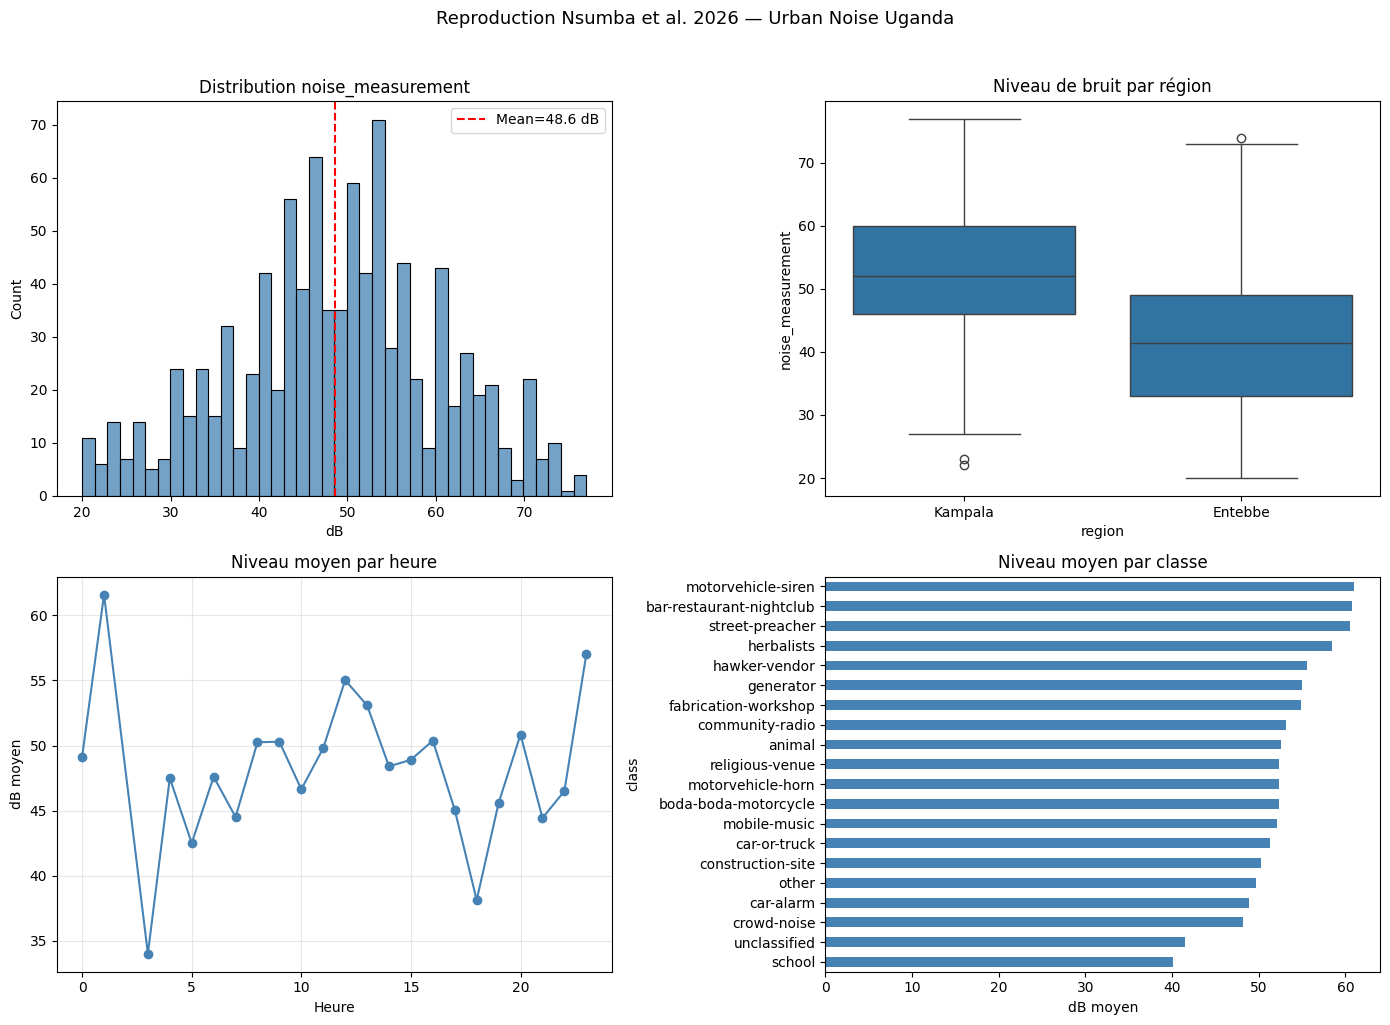

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution globale
sns.histplot(df['noise_measurement'], bins=40, ax=axes[0,0], color='steelblue')
axes[0,0].axvline(df['noise_measurement'].mean(), color='red', linestyle='--', label=f'Mean={df["noise_measurement"].mean():.1f} dB')
axes[0,0].set_title('Distribution noise_measurement')
axes[0,0].set_xlabel('dB')
axes[0,0].legend()

# Par région
sns.boxplot(data=df, x='region', y='noise_measurement', ax=axes[0,1])
axes[0,1].set_title('Niveau de bruit par région')

# Par heure de la journée
hourly = df.groupby('hour')['noise_measurement'].mean()
axes[1,0].plot(hourly.index, hourly.values, marker='o', color='steelblue')
axes[1,0].set_title('Niveau moyen par heure')
axes[1,0].set_xlabel('Heure')
axes[1,0].set_ylabel('dB moyen')
axes[1,0].grid(True, alpha=0.3)

# Par classe
class_means = df.groupby('class')['noise_measurement'].mean().sort_values()
class_means.plot(kind='barh', ax=axes[1,1], color='steelblue')
axes[1,1].set_title('Niveau moyen par classe')
axes[1,1].set_xlabel('dB moyen')

plt.suptitle('Reproduction Nsumba et al. 2026 — Urban Noise Uganda', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/maps/reproduce_sunbird.png', dpi=150, bbox_inches='tight')
plt.show()

## Étape 4 — Carte de couverture géographique

In [5]:
center = [df['latitude'].mean(), df['longitude'].mean()]
m = folium.Map(location=center, zoom_start=12, tiles='CartoDB positron')

def couleur(dB):
    if dB < 55:  return 'green'
    if dB < 70:  return 'orange'
    return 'red'

for _, row in df.sample(min(1000, len(df))).iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=3,
        color=couleur(row['noise_measurement']),
        fill=True,
        fill_opacity=0.7,
        popup=f"{row['noise_measurement']:.1f} dB — {row['class']}"
    ).add_to(m)

m.save('../outputs/maps/sunbird_coverage.html')
print('Carte sauvegardée → outputs/maps/sunbird_coverage.html')
m

Carte sauvegardée → outputs/maps/sunbird_coverage.html


In [6]:
# Sauvegarde le dataset nettoyé — input des notebooks 03 (audio QC), 04 (morphologie), 05 (figures)
cols = [c for c in ['noise_measurement', 'latitude', 'longitude', 'altitude', 'accuracy',
                    'class', 'class_id', 'region', 'timestamp', 'submitter_id',
                    'hour', 'day_of_week'] if c in df.columns]
df[cols].to_csv('../data/processed/sunbird_clean.csv', index=False)
print(f'{len(df)} lignes sauvegardées → data/processed/sunbird_clean.csv')

955 lignes sauvegardées → data/processed/sunbird_clean.csv


## Résumé — Ce qu'on a reproduit

| Étape papier | Reproduit |
|---|---|
| Suppression doublons | Oui |
| Filtre qualité GPS | Oui |
| Distribution noise_measurement | Oui |
| Analyse par région | Oui |
| Analyse temporelle (par heure) | Oui |
| Analyse par classe | Oui |
| Carte de couverture | Oui |

**Prochaine étape :** appliquer la même pipeline sur nos mesures terrain à Hanoï.